# Exact SOCP relaxation for DOPF — translated to Python (CVXPY + COPT)

This notebook reproduces the main steps of `ExactSOCPRforDOPF_sxw.m` and solves the SOCP relaxation using `cvxpy` with the `COPT` solver.

## 概述

本笔记本实现了配电最优潮流（DOPF）问题的精确二阶锥规划（SOCP）松弛，从MATLAB脚本 `ExactSOCPRforDOPF_sxw.m` 翻译而来。它使用CVXPY建模优化问题，并使用COPT求解器求解。目标是在满足配电网络中的电压和电流约束的同时，最小化来自电网的总功率注入。

In [1]:
# Imports and basic settings
import os
import numpy as np
import pandas as pd
import cvxpy as cp
import networkx as nx
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Check COPT availability
try:
    import coptpy  # optional: ensure COPT Python binding available
    has_copt = True
except Exception:
    has_copt = False

# System parameters
Ubase = 12.35e3  # Base voltage in V
Sbase = 1e7  # Base power in VA
Ibase = Sbase / (np.sqrt(3) * Ubase)  # Base current in A
Zbase = Ubase / Ibase / np.sqrt(3)  # Base impedance in Ω
I_max = 560.98 / Ibase  # Maximum current in p.u.
v_max = 1.1**2
v_min = 0.9**2

## 数据加载

本节从Excel文件（SCE47.xlsx）或MATLAB .mat文件加载网络数据。它提取：

- `loadpoint`：节点负荷数据，包括功率额定值和节点类型。

- `network_params`：线路参数，包括电阻、抗阻和连接性。

- 构造关联矩阵 `In` 并定义线路参数 `r`、`x`。

- 定义节点类型（`judge`）和功率容量（`So`）。

In [2]:
# Load data: try SCE47 Excel (sheets '网络参数' and '节点负荷'), else fallback to .mat files
def load_sce47():
    candidates = ['SCE47.xlsx', 'SCE47.xls', 'SCE47.XLSX', 'SCE47.XLS']
    found = None
    for fn in candidates:
        if os.path.exists(fn):
            found = fn
            break

    if found:
        sheets = pd.read_excel(found, sheet_name=None, header=0)  # Skip header row
        loadpoint = sheets['节点负荷']
        network_params = sheets['网络参数']
    else:
        mat_data = loadmat('SCE47.mat')
        loadpoint = mat_data['节点负荷']
        network_params = mat_data['网络参数']

    return loadpoint, network_params

# Load data
loadpoint, network_params = load_sce47()

# Define N and L based on the data
N = loadpoint.shape[0]  # Number of nodes
L = network_params.shape[0]  # Number of lines

# Generate incidence matrix
I = network_params.iloc[:, 1].values.astype(int)  # Starting nodes
J = network_params.iloc[:, 2].values.astype(int)  # Ending nodes
In = np.zeros((N, L))
for idx, (start, end) in enumerate(zip(I, J)):
    In[start - 1, idx] = 1
    In[end - 1, idx] = -1

# Define line parameters r and x
r = pd.to_numeric(network_params.iloc[:, 3]) / Zbase  # Resistance per line in p.u.
x = pd.to_numeric(network_params.iloc[:, 4]) / Zbase  # Reactance per line in p.u.

# Define Inn as the incidence matrix with positive entries set to zero
Inn = In.copy()
Inn[Inn > 0] = 0
    
# Define the judge variable based on the loadpoint data
judge = pd.to_numeric(loadpoint.iloc[:, 3])  # Extract node type from the 4th column of loadpoint
# Define the So variable based on the loadpoint data
So = pd.to_numeric(loadpoint.iloc[:, 2]) * 1e6 / Sbase  # Node power in p.u.

## 优化变量声明

本节定义了优化问题中的变量：

- `P_ij`: 线路上的有功功率流 (L 个变量)
- `Q_ij`: 线路上的无功功率流 (L 个变量)
- `v`: 节点处的电压幅值 (N 个变量)
- `l_ij`: 线路上的电流幅值平方 (L 个变量)
- `Pi`: 节点处的有功功率注入 (N 个变量)
- `Qi`: 节点处的无功功率注入 (N 个变量)

In [3]:
# Define optimization variables
P_ij = cp.Variable(L)
Q_ij = cp.Variable(L)
v = cp.Variable(N)
l_ij = cp.Variable(L)
Pi = cp.Variable(N)
Qi = cp.Variable(N)

## 约束

约束包括：

- **节点类型约束**：根据节点类型（电容器、负荷、光伏、松弛），设置有功和无功功率注入的界限。

- **电压和电流限制**：确保电压保持在界限内，电流不超过最大值。

- **电压计算**：使用关联矩阵将电压与功率流相关联。

- **SOC约束**：功率流方程的二阶锥松弛。

- **功率流约束**：平衡每个节点的有功和无功功率。

In [4]:
# Assemble constraints following MATLAB logic
constraints = []
Eta = 2

# Node type constraints
for i in range(N):
    if judge[i] == 1:  # Capacitor
        constraints.append(Pi[i] == 0)
        constraints.append(0 <= Qi[i])
        constraints.append(Qi[i] <= So[i] * Eta)
    elif judge[i] == 2:  # Load node
        constraints.append(Pi[i] == -So[i] * 0.9)
        constraints.append(Qi[i] == -So[i] * (1 - 0.9**2)**0.5)
    elif judge[i] == 0:  # PV panel
        constraints.append(0 <= Pi[i])
        constraints.append(Pi[i] <= So[i] * Eta)
        constraints.append(-0.1 <= Qi[i])  # Allow small reactive power
        constraints.append(Qi[i] <= 0.1)
    elif judge[i] == 3:  # Slack node
        constraints.append(-So[i] * 1.2 <= Pi[i])  # Relaxed bounds
        constraints.append(Pi[i] <= So[i] * 1.2)
        constraints.append(-So[i] * 0.6 <= Qi[i])
        constraints.append(Qi[i] <= So[i] * 0.6)

# Voltage and current limits
constraints.append(cp.square(l_ij) <= I_max**2)
constraints.append(v[1:] >= v_min)
constraints.append(v[1:] <= v_max)

# Voltage calculation constraints
constraints.append(v[0] == v_max)
constraints.append(In.T @ v == 2 * cp.multiply(r, P_ij) + 2 * cp.multiply(x, Q_ij) - cp.multiply(r**2 + x**2, l_ij))

# Second-Order Cone (SOC) constraints
for k in range(L):
    i = I[k]  # Starting node of line k
    constraints.append(cp.SOC(l_ij[k] + v[i], cp.hstack([2 * P_ij[k], 2 * Q_ij[k], l_ij[k] - v[i]])))

# Power flow constraints
constraints.append(In @ P_ij - Inn @ cp.multiply(r, l_ij) == Pi)
constraints.append(In @ Q_ij - Inn @ cp.multiply(x, l_ij) == Qi)

In [5]:
# Define the objective function
pv_indices = np.where(judge == 0)[0]
objective = cp.Minimize(cp.sum(Pi[pv_indices]) + Pi[0])

## 求解优化问题

使用CVXPY与COPT求解器（如果可用）求解问题。目标是最小化来自电网的有功和无功功率注入的总和。结果包括功率流、电压和电流的最优值。

In [6]:
# Solve the optimization problem
problem = cp.Problem(objective, constraints)
result = problem.solve(solver=cp.COPT if has_copt else cp.SCS)

# Display results
print("Optimal value:", result)
print("P_ij (p.u.):", P_ij.value)
print("Q_ij (p.u.):", Q_ij.value)
print("P_ij (MW):", P_ij.value * Sbase / 1e6)
print("Q_ij (MVAr):", Q_ij.value * Sbase / 1e6)
print("v:", v.value)
print("l_ij:", l_ij.value)

Optimal value: 1.0592226609451485
P_ij (p.u.): [ 1.13009718e-01 -2.99999952e-01  4.12829870e-01  4.97778227e-01
  8.01398241e-02 -1.65375726e-01 -1.31625586e-01  6.28770457e-01
  1.80013457e-02  6.08412258e-01  6.57699993e-02  5.42333592e-01
  5.40214445e-02  4.87807531e-01  1.17004303e-02  1.20843273e-01
  6.03265973e-02  8.29164637e-02  2.11823395e-01  1.41471641e-01
  7.02741101e-02  1.00926892e-01  4.05257088e-02  2.58162987e-05
  4.05085288e-02 -1.15971856e-01 -4.97234308e-02 -5.60377658e-02
 -1.76305382e-01 -1.72469833e-01  4.05235109e-02 -2.13890607e-01
  7.20768528e-04 -1.99979237e-01  6.30012468e-03  4.14203133e-02
  2.97077928e-02  1.80013491e-02  4.23063057e-02  1.80006858e-02
  2.43030666e-02  4.69910802e-05  4.05119962e-02  5.85224997e-02
  4.05068511e-02  1.80013532e-02]
Q_ij (p.u.): [-1.27129740e-03 -1.16716828e-03 -6.65046060e-04  6.63452821e-02
  3.88076196e-02  1.31751023e-03 -2.74016260e-03  6.78187367e-02
  8.71812880e-03  5.50697264e-02  3.18438245e-02  2.25879900e

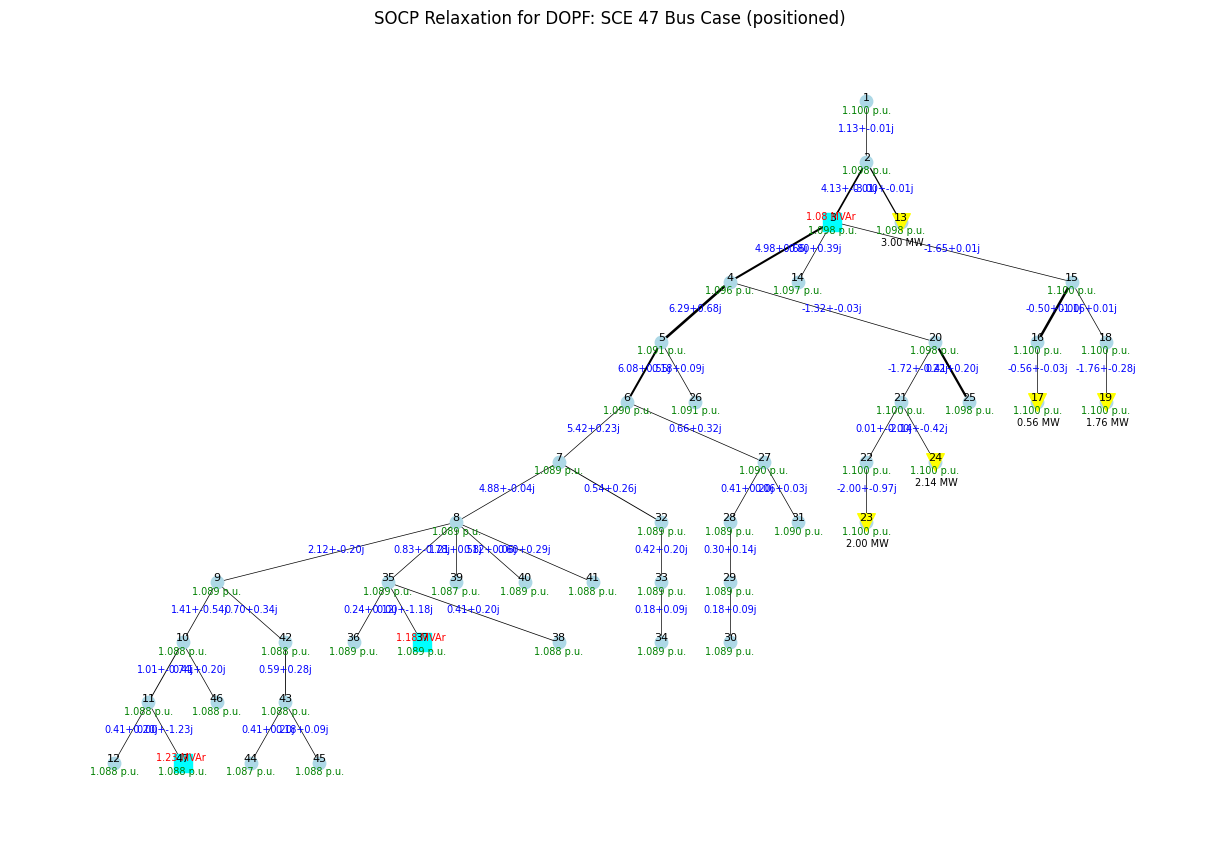

PV panel generation: 9.462 MW
Substation power: 1.130 MW


In [7]:
# Visualization of results
import matplotlib.pyplot as plt
import networkx as nx
import os

# Create graph
G = nx.Graph()
G.add_edges_from(zip(I, J))

# Load node coordinates from CSV
coords_file = 'SCE47node_coordinates.csv'
pos_df = pd.read_csv(coords_file, header=None, names=['x', 'y'])
pos = {i+1: (row['x'], row['y']) for i, row in pos_df.iterrows()}

# Save pos for reuse
np.save('SCE47_node_pos.npy', pos)

# Draw the graph using computed positions
plt.figure(figsize=(12, 8))
edge_widths = [max(0.5, 3 * abs(P_ij.value[k])) for k in range(len(P_ij.value))]
nx.draw(G, pos, with_labels=False, width=edge_widths, node_color='lightblue', node_size=80)

# Highlight capacitor nodes (judge == 1)
cap_nodes = [i+1 for i, j in enumerate(judge) if j == 1]
nx.draw_networkx_nodes(G, pos, nodelist=cap_nodes, node_color='cyan', node_shape='s', node_size=160)

# Highlight PV nodes (judge == 0)
pv_nodes = [i+1 for i, j in enumerate(judge) if j == 0]
nx.draw_networkx_nodes(G, pos, nodelist=pv_nodes, node_color='yellow', node_shape='v', node_size=160)

# Add node labels (numbers) near points
for node in G.nodes():
    x, y = pos[node]
    plt.text(x, y+0.02, str(node), horizontalalignment='center', fontsize=8, color='k')

# Add voltage labels (sqrt of v)
for node in G.nodes():
    x, y = pos[node]
    plt.text(x, y - 0.2, f'{np.sqrt(v.value[node-1]):.3f} p.u.', horizontalalignment='center', fontsize=7, color='g')

# Add Qi for capacitors
for node in cap_nodes:
    x, y = pos[node]
    plt.text(x - 0.02, y + 0.03, f'{Qi.value[node-1] * Sbase / 1e6:.2f} MVAr', horizontalalignment='center', fontsize=7, color='r')

# Add Pi for PV
for node in pv_nodes:
    x, y = pos[node]
    plt.text(x + 0.02, y - 0.4, f'{Pi.value[node-1] * Sbase / 1e6:.2f} MW', horizontalalignment='center', fontsize=7, color='k')

# Add power flow on edges (midpoint)
for k, (i, j) in enumerate(zip(I, J)):
    mid_x = (pos[i][0] + pos[j][0]) / 2
    mid_y = (pos[i][1] + pos[j][1]) / 2
    p_flow = P_ij.value[k] * Sbase / 1e6
    q_flow = Q_ij.value[k] * Sbase / 1e6
    if abs(p_flow) > 1e-6 or abs(q_flow) > 1e-6:
        plt.text(mid_x, mid_y, f'{p_flow:.2f}+{q_flow:.2f}j', horizontalalignment='center', fontsize=7, color='blue')

plt.title('SOCP Relaxation for DOPF: SCE 47 Bus Case (positioned)')
plt.axis('off')
plt.show()

# Display some results
pv_total = sum(Pi.value[[i-1 for i in pv_nodes]]) * Sbase / 1e6
print(f'PV panel generation: {pv_total:.3f} MW')
print(f'Substation power: {Pi.value[0] * Sbase / 1e6:.3f} MW')

In [ ]:
# Inspect the dimensions and content of loadpoint and network_params
print("loadpoint shape:", loadpoint.shape)
print("network_params shape:", network_params.shape)
print("loadpoint head:")
print(loadpoint.head())
print("network_params head:")
print(network_params.head())

## 结论

本笔记本成功地将MATLAB的DOPF SOCP松弛翻译为使用CVXPY的Python。它演示了数据加载、约束制定和优化求解。结果可用于分析配电网络的最优运行。